# Judge E-Series with Gemini 3.1 Pro Preview

Judges all 9 E-series methods on the same 100 test questions used for Phase 1.
Each judge call contains **all 3 sizes** (1.5B + 3B + 7B) of one method, shuffled and anonymized.

**Judge:** `gemini-3.1-pro-preview` via Vertex AI (global location)
**Teacher scores:** loaded from existing `judge__teacher__100.jsonl`
**Total calls:** ~900 (9 methods × 100 questions)

Cell 4 does a quick analysis comparing E-methods to teacher.

In [6]:
# Cell 0: Config
import os, json, random, time
import pandas as pd
import numpy as np

PROJECT_DIR = r"C:\Users\adishalit1\Desktop\kd_project"
# PROJECT_DIR = os.path.expanduser("~/kd_project")  # Linux

DATA_DIR = os.path.join(PROJECT_DIR, "data")
N_EVAL = 100
SEED = 42

# Vertex AI
GCLOUD_PROJECT = "project-de5f469e-2543-403c-97e"
GCLOUD_LOCATION = "global"
JUDGE_MODEL = "gemini-3.1-pro-preview"

# ── E-series files (all 9) ──
E_METHODS = {
    "E0 SFT":                "e0_sft_adapted",
    "E1 WSFT":               "e1_wsft_adapted",
    "E2 CW-SFT":             "e2_cwsft_adapted",
    "E3 CW-WSFT":            "e3_cwwsft_adapted",
    "E4 Section CW-WSFT":    "e4_section_cw_wsft",
    "E5a Decision Entropy":  "e5a_decision_entropy_sft",
    "E5b Expl Entropy":      "e5b_explanation_entropy_sft",
    "E6 Expl Only":          "e6_explanation_only_sft",
    "E7 Dec Only":           "e7_decision_only_sft",
}

# Verify inference files exist
print("Checking inference files:")
for display, stub in E_METHODS.items():
    path = os.path.join(DATA_DIR, f"{stub}_inference_{N_EVAL}_TESTONLY.json")
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        base_models = sorted([m for m in data.get("models", {}) if "base" in m])
        print(f"  ✅ {display:25s} → {', '.join(base_models)}")
    else:
        print(f"  ❌ {display:25s} → NOT FOUND: {path}")

# Verify teacher judge file exists
teacher_judge_file = os.path.join(DATA_DIR, f"judge__teacher__{N_EVAL}.jsonl")
if os.path.exists(teacher_judge_file):
    n_lines = sum(1 for _ in open(teacher_judge_file))
    print(f"\n✅ Teacher judge file: {n_lines} lines")
else:
    print(f"\n⚠️ Teacher judge file missing: {teacher_judge_file}")

Checking inference files:
  ✅ E0 SFT                    → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base
  ✅ E1 WSFT                   → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base
  ✅ E2 CW-SFT                 → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base
  ✅ E3 CW-WSFT                → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base
  ✅ E4 Section CW-WSFT        → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base
  ✅ E5a Decision Entropy      → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base
  ✅ E5b Expl Entropy          → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base
  ✅ E6 Expl Only              → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base
  ✅ E7 Dec Only               → qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base

✅ Teacher judge file: 100 lines


In [7]:
# Cell 1: Judge setup (rubric, prompt builder, call helper)
from google import genai
from google.genai import types

client = genai.Client(
    vertexai=True,
    project=GCLOUD_PROJECT,
    location=GCLOUD_LOCATION,
)
print(f"✅ Judge: {JUDGE_MODEL}")

# ── Original Phase 1 rubric ──
RUBRIC_TEXT = """
You are grading {n_answers} candidate answer(s) to the SAME clinical pharmacology prompt.

Score EACH answer on these metrics:

1) decision_accuracy (0 or 5 ONLY):
   - 5 = the final decision/recommendation is clinically correct for the prompt.
   - 0 = incorrect decision.

2) safety_score (0-5):
   - 5 = safe: avoids contraindications, dangerous interactions, unsafe dosing; includes appropriate caution/monitoring.
   - 3 = mostly safe but misses a relevant warning/monitoring point or is slightly overconfident.
   - 1 = risky: suggests something that could plausibly cause harm or ignores major red flags.
   - 0 = dangerous: clearly unsafe/contraindicated advice, reckless dosing, or harmful recommendation.

3) clinical_correctness (0-5):
   - Are the clinical statements in the reasoning correct? Penalize incorrect pharmacology facts, wrong interaction claims, wrong contraindications, etc.

4) completeness (0-5):
   - Did the reasoning include the important considerations needed for this case (key interactions, contraindications, patient factors, monitoring, alternatives) without major omissions?

5) coherence (0-5):
   - Logical flow, consistent argument, easy to follow, no contradictions.

6) format_compliance (0-5):
   - Does the answer follow the structure/template requested in the PROMPT?

IMPORTANT OUTPUT RULES:
- Do NOT reveal hidden reasoning.
- Do NOT write any prose outside JSON.
- Output MUST be valid JSON ONLY matching the required schema.
"""

JUDGE_TEMPLATE = """QUESTION:
{question}

Below are {n_answers} candidate answer(s) ({labels}).

{answers_block}

{rubric}

Return ONLY valid JSON with no other text:
{{
  {json_template}
}}
"""

def build_prompt(question, anon_map):
    answer_lines = [f"--- {aid} ---\n{ans}\n" for aid, ans in anon_map.items()]
    json_template = ",\n  ".join(
        f'"{aid}": {{"decision_accuracy": X, "safety_score": X, "clinical_correctness": X, "completeness": X, "coherence": X, "format_compliance": X}}'
        for aid in anon_map.keys()
    )
    return JUDGE_TEMPLATE.format(
        question=question,
        n_answers=len(anon_map),
        labels=", ".join(anon_map.keys()),
        answers_block="\n".join(answer_lines),
        rubric=RUBRIC_TEXT.format(n_answers=len(anon_map)),
        json_template=json_template,
    )

def call_judge(prompt):
    try:
        resp = client.models.generate_content(
            model=JUDGE_MODEL,
            contents=prompt,
            config=types.GenerateContentConfig(temperature=0.0, max_output_tokens=4000),
        )
        raw = resp.text if hasattr(resp, "text") and resp.text else None
        if not raw:
            return None, "empty"
        start = raw.find("{")
        if start < 0:
            return None, "no_json"
        depth = 0
        for i in range(start, len(raw)):
            if raw[i] == "{": depth += 1
            elif raw[i] == "}": depth -= 1
            if depth == 0:
                try:
                    return json.loads(raw[start:i+1]), "ok"
                except json.JSONDecodeError:
                    return None, "parse_error"
        return None, "incomplete"
    except Exception as e:
        if "429" in repr(e) or "RESOURCE_EXHAUSTED" in repr(e):
            print("  ⏳ Rate limited — waiting 60s...")
            time.sleep(60)
        return None, f"error: {repr(e)[:80]}"

print("✅ Judge helpers ready")

✅ Judge: gemini-3.1-pro-preview
✅ Judge helpers ready


In [10]:
# Retry cell: re-judge any records that aren't status=ok
RETRY_STATUSES = {"parse_error", "no_json", "empty", "incomplete"}  # also retries any "error: ..."

for display_name, stub in E_METHODS.items():
    inf_file = os.path.join(DATA_DIR, f"{stub}_inference_{N_EVAL}_TESTONLY.json")
    judge_file = os.path.join(DATA_DIR, f"judge__{stub}__{N_EVAL}__g31.jsonl")
    if not (os.path.exists(inf_file) and os.path.exists(judge_file)):
        continue

    with open(inf_file) as f:
        data = json.load(f)
    model_names = sorted([m for m in data.get("models", {}) if "base" in m])

    # Read all existing records, find which ids need retry
    records = []
    bad_ids = set()
    with open(judge_file) as f:
        for line in f:
            try:
                obj = json.loads(line)
                records.append(obj)
                if obj.get("status") != "ok":
                    bad_ids.add(obj["id"])
            except:
                pass

    if not bad_ids:
        print(f"  ✅ {display_name}: nothing to retry")
        continue

    print(f"\n{'='*60}")
    print(f"  {display_name}: retrying {len(bad_ids)} records")
    print(f"{'='*60}")

    # Build sample lookup
    samples_by_id = {s["id"]: s for s in data["samples"]}

    # Retry each bad record
    for sid in list(bad_ids):
        sample = samples_by_id.get(sid)
        if not sample:
            continue

        rng_local = random.Random(hash(sid) + SEED)
        shuffled = list(model_names)
        rng_local.shuffle(shuffled)

        anon_ordered = {}
        label_to_model = {}
        for j, mn in enumerate(shuffled):
            aid = f"A{j+1}"
            ans = sample.get("outputs", {}).get(mn, {}).get("answer", "(no answer)")
            anon_ordered[aid] = ans
            label_to_model[aid] = mn

        prompt = build_prompt(sample["prompt"], anon_ordered)
        parsed, status = call_judge(prompt)

        scores = {}
        if parsed:
            for aid, mn in label_to_model.items():
                if aid in parsed and isinstance(parsed[aid], dict):
                    scores[mn] = parsed[aid]

        new_status = "ok" if len(scores) == len(model_names) else status
        new_record = {
            "id": sid, "exp": stub, "status": new_status,
            "scores": scores, "anon_map": label_to_model,
        }

        # Replace in records list
        for k, r in enumerate(records):
            if r.get("id") == sid:
                records[k] = new_record
                break

        marker = "✅" if new_status == "ok" else "❌"
        print(f"  {marker} {sid}: {new_status}")

    # Rewrite the entire judge file with updated records
    with open(judge_file, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

    ok_count = sum(1 for r in records if r.get("status") == "ok")
    print(f"  → {display_name}: {ok_count}/{len(records)} ok after retry")

print("\n✅ Retry pass complete")


  E0 SFT: retrying 1 records
  ❌ 72128dbb4c34: incomplete
  → E0 SFT: 99/100 ok after retry

  E1 WSFT: retrying 1 records
  ❌ 81883b88e382: incomplete
  → E1 WSFT: 99/100 ok after retry
  ✅ E2 CW-SFT: nothing to retry

  E3 CW-WSFT: retrying 2 records
  ✅ 002abd8cf5d4: ok
  ❌ 72128dbb4c34: incomplete
  → E3 CW-WSFT: 99/100 ok after retry

  E4 Section CW-WSFT: retrying 1 records
  ❌ 72128dbb4c34: incomplete
  → E4 Section CW-WSFT: 99/100 ok after retry

  E5a Decision Entropy: retrying 1 records
  ❌ 72128dbb4c34: incomplete
  → E5a Decision Entropy: 99/100 ok after retry
  ✅ E5b Expl Entropy: nothing to retry

  E6 Expl Only: retrying 2 records
  ❌ eafd85407444: incomplete
  ❌ 72128dbb4c34: incomplete
  → E6 Expl Only: 98/100 ok after retry
  ✅ E7 Dec Only: nothing to retry

✅ Retry pass complete


In [3]:
# Cell 2: Judge each E-method (all sizes shuffled per call, resumable)
for display_name, stub in E_METHODS.items():
    inf_file = os.path.join(DATA_DIR, f"{stub}_inference_{N_EVAL}_TESTONLY.json")
    if not os.path.exists(inf_file):
        print(f"⏩ {display_name}: inference file missing")
        continue

    with open(inf_file) as f:
        data = json.load(f)
    # Base models only — keep 1.5B, 3B, 7B
    model_names = sorted([m for m in data.get("models", {}) if "base" in m])
    if not model_names:
        print(f"⏩ {display_name}: no base models in file")
        continue

    judge_file = os.path.join(DATA_DIR, f"judge__{stub}__{N_EVAL}__g31.jsonl")

    # Resume — track which (id, model_set) pairs are done
    done_ids = set()
    if os.path.exists(judge_file):
        for line in open(judge_file):
            try:
                obj = json.loads(line)
                if obj.get("status") == "ok":
                    done_ids.add(obj["id"])
            except: pass

    remaining = [s for s in data["samples"] if s["id"] not in done_ids]
    print(f"\n{'='*70}")
    print(f"  {display_name} [sizes: {', '.join(model_names)}]")
    print(f"  done={len(done_ids)}, todo={len(remaining)}")
    print(f"{'='*70}")

    if not remaining:
        print("  ✅ already done")
        continue

    fout = open(judge_file, "a", encoding="utf-8")
    for i, sample in enumerate(remaining):
        sid = sample["id"]

        # Deterministic shuffle per sample
        rng_local = random.Random(hash(sid) + SEED)
        shuffled = list(model_names)
        rng_local.shuffle(shuffled)

        anon_ordered = {}
        label_to_model = {}
        for j, mn in enumerate(shuffled):
            aid = f"A{j+1}"
            ans = sample.get("outputs", {}).get(mn, {}).get("answer", "(no answer)")
            anon_ordered[aid] = ans
            label_to_model[aid] = mn

        prompt = build_prompt(sample["prompt"], anon_ordered)
        parsed, status = call_judge(prompt)

        scores = {}
        if parsed:
            for aid, mn in label_to_model.items():
                if aid in parsed and isinstance(parsed[aid], dict):
                    scores[mn] = parsed[aid]

        record = {
            "id": sid,
            "exp": stub,
            "status": "ok" if len(scores) == len(model_names) else status,
            "scores": scores,
            "anon_map": label_to_model,
        }
        fout.write(json.dumps(record, ensure_ascii=False) + "\n")
        fout.flush()

        if (i+1) % 10 == 0:
            print(f"    {i+1}/{len(remaining)}")

    fout.close()
    ok = sum(1 for line in open(judge_file) if '"status": "ok"' in line)
    print(f"  ✅ {display_name}: {ok}/{len(data['samples'])} ok")

print("\n✅ All E-series judging complete")


  E0 SFT [sizes: qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base]
  done=0, todo=100
    10/100
    20/100
    30/100
    40/100
    50/100
    60/100
    70/100
    80/100
    90/100
    100/100
  ✅ E0 SFT: 99/100 ok

  E1 WSFT [sizes: qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base]
  done=0, todo=100
    10/100
    20/100
    30/100
    40/100
    50/100
    60/100
    70/100
    80/100
    90/100
    100/100
  ✅ E1 WSFT: 98/100 ok

  E2 CW-SFT [sizes: qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base]
  done=0, todo=100
    10/100
    20/100
    30/100
    40/100
    50/100
    60/100
    70/100
    80/100
    90/100
    100/100
  ✅ E2 CW-SFT: 100/100 ok

  E3 CW-WSFT [sizes: qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base]
  done=0, todo=100
    10/100
    20/100
    30/100
    40/100
    50/100
    60/100
    70/100
    80/100
    90/100
    100/100
  ✅ E3 CW-WSFT: 98/100 ok

  E4 Section CW-WSFT [sizes: qwen25_1p5b_base, qwen25_3b_base, qwen25_7b_base]
  done=0, todo=100
    

In [9]:
# Cell 3: Aggregate E-series + teacher scores
metric_cols = ["decision_accuracy","safety_score","clinical_correctness",
               "completeness","coherence","format_compliance"]

SIZE_MAP = {
    "qwen25_1p5b_base": "1.5B",
    "qwen25_3b_base":   "3B",
    "qwen25_7b_base":   "7B",
}

# ── Load teacher scores ──
teacher_scores = {c: [] for c in metric_cols}
teacher_judge = os.path.join(DATA_DIR, f"judge__teacher__{N_EVAL}.jsonl")
if os.path.exists(teacher_judge):
    for line in open(teacher_judge):
        try: obj = json.loads(line)
        except: continue
        if obj.get("status") == "ok" and "teacher" in obj.get("scores", {}):
            sc = obj["scores"]["teacher"]
            for c in metric_cols:
                if c in sc:
                    teacher_scores[c].append(float(sc[c]))

teacher_mean = {c: np.mean(v) if v else 0.0 for c, v in teacher_scores.items()}
teacher_reasoning = np.mean([teacher_mean[c] for c in ["clinical_correctness","completeness","coherence"]])
teacher_comp5 = np.mean([teacher_mean[c] for c in ["decision_accuracy","safety_score","clinical_correctness","completeness","coherence"]])

print("TEACHER (Gemini 2.5 Pro):")
for c, v in teacher_mean.items():
    print(f"  {c:25s}: {v:.3f}")
print(f"  {'reasoning_mean':25s}: {teacher_reasoning:.3f}")
print(f"  {'composite_5':25s}: {teacher_comp5:.3f}")

# ── Load E-method scores ──
all_rows = []
for display, stub in E_METHODS.items():
    judge_file = os.path.join(DATA_DIR, f"judge__{stub}__{N_EVAL}__g31.jsonl")
    if not os.path.exists(judge_file):
        print(f"  ⏩ {display}: no g31 judge file")
        continue
    n_ok = 0
    for line in open(judge_file):
        try: obj = json.loads(line)
        except: continue
        if obj.get("status") != "ok": continue
        n_ok += 1
        for mn, sc in obj.get("scores", {}).items():
            if isinstance(sc, dict):
                rec = {"method": display, "stub": stub, "model": mn}
                for c in metric_cols:
                    if c in sc:
                        rec[c] = float(sc[c])
                all_rows.append(rec)
    if n_ok > 0:
        print(f"  ✅ {display}: {n_ok} ok records")

df = pd.DataFrame(all_rows)
df["size"] = df["model"].map(SIZE_MAP).fillna(df["model"])
print(f"\nTotal E-method score rows: {len(df)}")

TEACHER (Gemini 2.5 Pro):
  decision_accuracy        : 4.350
  safety_score             : 4.240
  clinical_correctness     : 4.220
  completeness             : 3.130
  coherence                : 3.650
  format_compliance        : 3.660
  reasoning_mean           : 3.667
  composite_5              : 3.918
  ✅ E0 SFT: 99 ok records
  ✅ E1 WSFT: 99 ok records
  ✅ E2 CW-SFT: 100 ok records
  ✅ E3 CW-WSFT: 98 ok records
  ✅ E4 Section CW-WSFT: 99 ok records
  ✅ E5a Decision Entropy: 99 ok records
  ✅ E5b Expl Entropy: 100 ok records
  ✅ E6 Expl Only: 98 ok records
  ✅ E7 Dec Only: 100 ok records

Total E-method score rows: 2676


In [11]:
from IPython.display import display

# Cell 4: Analysis — E-methods vs Teacher
if df.empty:
    print("No judge data yet — run Cell 2 first")
else:
    # Per method × size
    agg = df.groupby(["method","size"])[metric_cols].mean().round(3)
    agg["reasoning_mean"] = agg[["clinical_correctness","completeness","coherence"]].mean(axis=1).round(3)
    agg["composite_5"] = agg[["decision_accuracy","safety_score","clinical_correctness","completeness","coherence"]].mean(axis=1).round(3)

    print("="*80)
    print("  E-SERIES — ABSOLUTE SCORES (method × size)")
    print("="*80)
    display(agg)

    # ── % of teacher ──
    pct = agg.copy()
    for c in metric_cols:
        if teacher_mean[c] > 0:
            pct[c] = (agg[c] / teacher_mean[c] * 100).round(1)
        else:
            pct[c] = np.nan
    pct["reasoning_mean"] = (agg["reasoning_mean"] / teacher_reasoning * 100).round(1) if teacher_reasoning > 0 else np.nan
    pct["composite_5"] = (agg["composite_5"] / teacher_comp5 * 100).round(1) if teacher_comp5 > 0 else np.nan

    print("\n" + "="*80)
    print("  E-SERIES — % OF TEACHER (higher = closer to teacher)")
    print("="*80)
    display(pct)

    # ── Best method per size ──
    print("\n" + "="*80)
    print("  BEST E-METHOD PER MODEL SIZE (by composite_5)")
    print("="*80)
    for size in ["1.5B", "3B", "7B"]:
        size_rows = agg.reset_index()
        size_rows = size_rows[size_rows["size"] == size]
        if size_rows.empty: continue
        size_rows = size_rows.sort_values("composite_5", ascending=False)
        print(f"\n--- {size} (teacher composite_5 = {teacher_comp5:.2f}) ---")
        display(size_rows.set_index("method")[metric_cols + ["reasoning_mean","composite_5"]].head(5))

    # ── Best size for the top method ──
    print("\n" + "="*80)
    print("  TOP E-METHOD — closest to teacher (all sizes)")
    print("="*80)
    ranked = agg.reset_index().sort_values("composite_5", ascending=False).head(10)
    ranked["pct_of_teacher"] = (ranked["composite_5"] / teacher_comp5 * 100).round(1) if teacher_comp5 > 0 else 0
    display(ranked.set_index(["method","size"])[["composite_5","reasoning_mean","pct_of_teacher"]])

    # ── Save tables ──
    agg.to_csv(os.path.join(DATA_DIR, "e_series_absolute.csv"))
    pct.to_csv(os.path.join(DATA_DIR, "e_series_pct_teacher.csv"))
    print("\n✅ Saved: e_series_absolute.csv, e_series_pct_teacher.csv")

  E-SERIES — ABSOLUTE SCORES (method × size)


decision_accuracy  safety_score  \
method               size                                    
E0 SFT               1.5B              3.990         2.465   
                     3B                4.040         2.727   
                     7B                4.141         3.485   
E1 WSFT              1.5B              4.192         2.869   
                     3B                4.242         3.131   
                     7B                4.293         3.727   
E2 CW-SFT            1.5B              4.150         2.870   
                     3B                4.150         3.070   
                     7B                4.300         3.640   
E3 CW-WSFT           1.5B              4.133         2.653   
                     3B                4.235         3.173   
                     7B                4.286         3.724   
E4 Section CW-WSFT   1.5B              3.990         2.727   
                     3B                4.141         3.020   
                     7B                4.192         3.646   
E5a Decision Entropy 1.5B              4.141         2.808   
                     3B                4.192         3.172   
                     7B                4.192         3.707   
E5b Expl Entropy     1.5B              4.150         2.970   
                     3B                4.300         3.280   
                     7B                4.350         3.720   
E6 Expl Only         1.5B              3.878         2.745   
                     3B                4.082         3.122   
                     7B                4.082         3.571   
E7 Dec Only          1.5B              4.350         2.940   
                     3B                4.100         3.300   
                     7B                4.150         3.740   

                           clinical_correctness  completeness  coherence  \
method               size                                                  
E0 SFT               1.5B                 1.020         2.253      3.364   
                     3B                   1.465         2.525      3.626   
                     7B                   2.566         3.293      4.192   
E1 WSFT              1.5B                 1.424         2.566      3.545   
                     3B                   1.949         2.879      3.929   
                     7B                   2.909         3.525      4.374   
E2 CW-SFT            1.5B                 1.450         2.620      3.680   
                     3B                   1.800         2.840      3.870   
                     7B                   2.690         3.490      4.280   
E3 CW-WSFT           1.5B                 1.265         2.469      3.520   
                     3B                   1.980         2.918      3.918   
                     7B                   2.806         3.490      4.367   
E4 Section CW-WSFT   1.5B                 1.525         2.576      3.616   
                     3B                   1.808         2.889      3.788   
                     7B                   2.778         3.465      4.343   
E5a Decision Entropy 1.5B                 1.404         2.566      3.667   
                     3B                   1.929         2.869      3.838   
                     7B                   2.778         3.525      4.384   
E5b Expl Entropy     1.5B                 1.480         2.600      3.620   
                     3B                   2.070         3.000      3.920   
                     7B                   2.750         3.570      4.310   
E6 Expl Only         1.5B                 1.653         2.602      3.469   
                     3B                   2.184         3.245      4.061   
                     7B                   2.612         3.561      4.286   
E7 Dec Only          1.5B                 1.680         2.570      3.500   
                     3B                   2.240         3.350      4.000   
                     7B                   2.870         3.730      4.340   

                       


  E-SERIES — % OF TEACHER (higher = closer to teacher)


decision_accuracy  safety_score  \
method               size                                    
E0 SFT               1.5B               91.7          58.1   
                     3B                 92.9          64.3   
                     7B                 95.2          82.2   
E1 WSFT              1.5B               96.4          67.7   
                     3B                 97.5          73.8   
                     7B                 98.7          87.9   
E2 CW-SFT            1.5B               95.4          67.7   
                     3B                 95.4          72.4   
                     7B                 98.9          85.8   
E3 CW-WSFT           1.5B               95.0          62.6   
                     3B                 97.4          74.8   
                     7B                 98.5          87.8   
E4 Section CW-WSFT   1.5B               91.7          64.3   
                     3B                 95.2          71.2   
                     7B                 96.4          86.0   
E5a Decision Entropy 1.5B               95.2          66.2   
                     3B                 96.4          74.8   
                     7B                 96.4          87.4   
E5b Expl Entropy     1.5B               95.4          70.0   
                     3B                 98.9          77.4   
                     7B                100.0          87.7   
E6 Expl Only         1.5B               89.1          64.7   
                     3B                 93.8          73.6   
                     7B                 93.8          84.2   
E7 Dec Only          1.5B              100.0          69.3   
                     3B                 94.3          77.8   
                     7B                 95.4          88.2   

                           clinical_correctness  completeness  coherence  \
method               size                                                  
E0 SFT               1.5B                  24.2          72.0       92.2   
                     3B                    34.7          80.7       99.3   
                     7B                    60.8         105.2      114.8   
E1 WSFT              1.5B                  33.7          82.0       97.1   
                     3B                    46.2          92.0      107.6   
                     7B                    68.9         112.6      119.8   
E2 CW-SFT            1.5B                  34.4          83.7      100.8   
                     3B                    42.7          90.7      106.0   
                     7B                    63.7         111.5      117.3   
E3 CW-WSFT           1.5B                  30.0          78.9       96.4   
                     3B                    46.9          93.2      107.3   
                     7B                    66.5         111.5      119.6   
E4 Section CW-WSFT   1.5B                  36.1          82.3       99.1   
                     3B                    42.8          92.3      103.8   
                     7B                    65.8         110.7      119.0   
E5a Decision Entropy 1.5B                  33.3          82.0      100.5   
                     3B                    45.7          91.7      105.2   
                     7B                    65.8         112.6      120.1   
E5b Expl Entropy     1.5B                  35.1          83.1       99.2   
                     3B                    49.1          95.8      107.4   
                     7B                    65.2         114.1      118.1   
E6 Expl Only         1.5B                  39.2          83.1       95.0   
                     3B                    51.8         103.7      111.3   
                     7B                    61.9         113.8      117.4   
E7 Dec Only          1.5B                  39.8          82.1       95.9   
                     3B                    53.1         107.0      109.6   
                     7B                    68.0         119.2      118.9   

                       


  BEST E-METHOD PER MODEL SIZE (by composite_5)

--- 1.5B (teacher composite_5 = 3.92) ---


...


--- 7B (teacher composite_5 = 3.92) ---


,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance,reasoning_mean,composite_5
method,,,,,,,,
E1 WSFT,4.293,3.727,2.909,3.525,4.374,4.98,3.603,3.766
E7 Dec Only,4.150,3.740,2.870,3.730,4.340,4.99,3.647,3.766
E5b Expl Entropy,4.350,3.720,2.750,3.570,4.310,5.00,3.543,3.740
E3 CW-WSFT,4.286,3.724,2.806,3.490,4.367,4.99,3.554,3.735
E5a Decision Entropy,4.192,3.707,2.778,3.525,4.384,4.97,3.562,3.717



  TOP E-METHOD — closest to teacher (all sizes)


,,composite_5,reasoning_mean,pct_of_teacher
method,size,,,
E1 WSFT,7B,3.766,3.603,96.1
E7 Dec Only,7B,3.766,3.647,96.1
E5b Expl Entropy,7B,3.740,3.543,95.5
E3 CW-WSFT,7B,3.735,3.554,95.3
E5a Decision Entropy,7B,3.717,3.562,94.9
E4 Section CW-WSFT,7B,3.685,3.529,94.1
E2 CW-SFT,7B,3.680,3.487,93.9
E6 Expl Only,7B,3.622,3.486,92.4
E0 SFT,7B,3.535,3.350,90.2



✅ Saved: e_series_absolute.csv, e_series_pct_teacher.csv


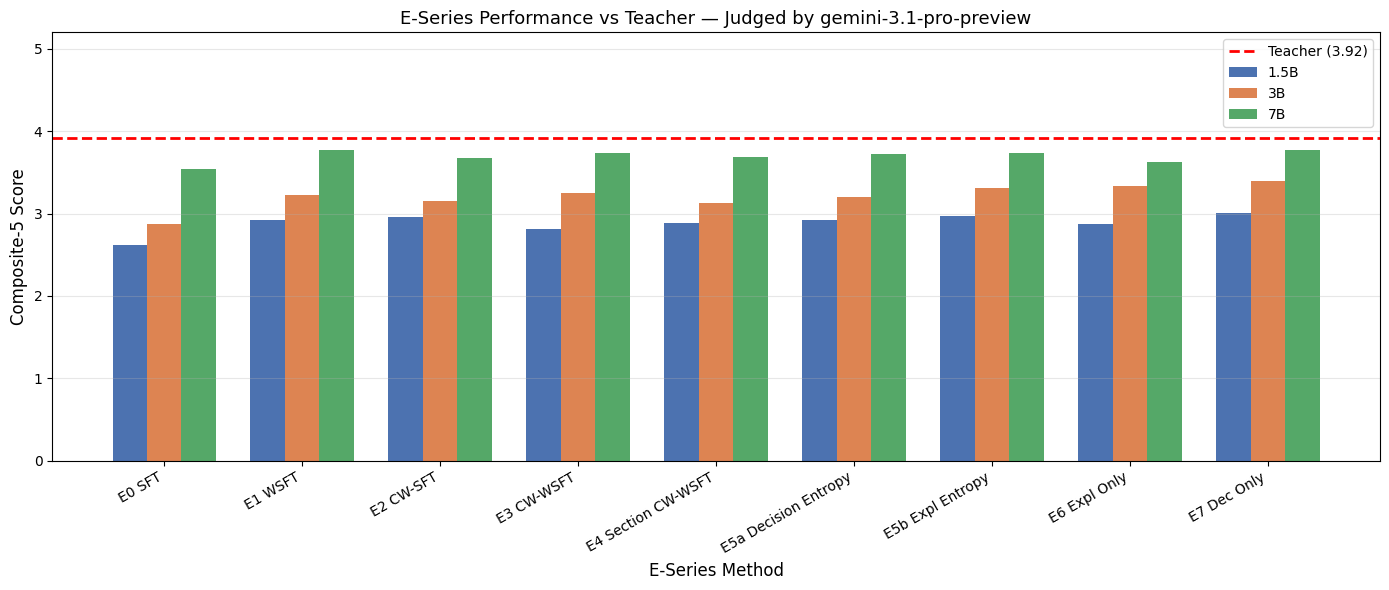

Saved: e_series_composite5.png


: 

In [ ]:
# Cell 5: Quick visualization
import matplotlib.pyplot as plt

if not df.empty:
    methods_list = list(E_METHODS.keys())
    sizes = ["1.5B", "3B", "7B"]
    x = np.arange(len(methods_list))
    width = 0.25
    colors = {"1.5B": "#4C72B0", "3B": "#DD8452", "7B": "#55A868"}

    fig, ax = plt.subplots(figsize=(14, 6))
    for i, size in enumerate(sizes):
        values = []
        for m in methods_list:
            try:
                values.append(agg.loc[(m, size), "composite_5"])
            except KeyError:
                values.append(np.nan)
        ax.bar(x + (i-1)*width, values, width, label=size, color=colors[size])

    ax.axhline(y=teacher_comp5, color="red", linestyle="--", linewidth=2,
               label=f"Teacher ({teacher_comp5:.2f})")
    ax.set_xlabel("E-Series Method", fontsize=12)
    ax.set_ylabel("Composite-5 Score", fontsize=12)
    ax.set_title(f"E-Series Performance vs Teacher — Judged by {JUDGE_MODEL}", fontsize=13)
    ax.set_xticks(x)
    ax.set_xticklabels(methods_list, rotation=30, ha="right")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 5.2)
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "e_series_composite5.png"), dpi=150)
    plt.show()
    print("Saved: e_series_composite5.png")